# Historical espresso exploration
Read-only analysis of the **current** staging CSV. Run all cells after installing `.[dev,analysis]`.
The typed calculations live in `espresso_dialin.historical`; this notebook presents their results.

Settings are exact categories in first-observed order, not a calibrated fineness scale. Contiguous bean labels are conservative analysis blocks, **not verified sessions**. No missing measurement is inferred. Approximate corrected puck doses retain that interpretation; their uncertainty is not numerically invented.


In [1]:
import hashlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from espresso_dialin.historical import (
    describe,
    eligible,
    exclusion_reasons,
    load_shots,
    metric,
    research_report,
)

ROOT = Path.cwd()
if not (ROOT / "data/historical_shots_staging.csv").exists():
    ROOT = ROOT.parent
DATA = ROOT / "data/historical_shots_staging.csv"
shots = load_shots(DATA)
report = research_report(shots)
print("Python", sys.version)
print("CSV SHA256", hashlib.sha256(DATA.read_bytes()).hexdigest())

Python 3.14.2 (tags/v3.14.2:df79316, Dec  5 2025, 17:18:21) [MSC v.1944 64 bit (AMD64)]
CSV SHA256 882392feecf6e23e2747f6de70d656e15e73caf208d14327a11a4ec3d361ce49


## Audit and explicit eligibility
Output-rate analysis needs positive duration and grinder output; categorical output comparisons also need a setting and bean label. Yield-pair analysis only needs positive brew time and final yield. Primary extraction additionally requires exact setting, bean label and a usable dose interpretation (`TO_TARGET`, `MEASURED`, or consistent `NONE`). `UNKNOWN` is excluded even if the puck column says 18 g. `partial` is not a global exclusion. The approximate output on shot 40 is retained with a sensitivity check below.

Chronological changes require immediate original neighbours with consecutive sequence numbers, known settings and the same block. Missing rows/settings are never bridged. The extraction rolling comparison may use earlier known shots at the same exact setting within the block; it makes no adjacency claim.


In [2]:
audit = report["audit"]
display(pd.Series({"rows": audit["rows"], **audit["statuses"]}, name="count"))
display(pd.DataFrame(audit["eligibility_by_bean"]).T)
display(pd.Series(audit["missingness"], name="blank_cells").to_frame())
exclusions = [
    {
        "analysis": analysis,
        "sequence": shot.sequence,
        "status": shot.raw["transcription_status"],
        "reasons": ", ".join(reasons),
    }
    for analysis in ("output", "setting_output", "yield_pair", "extraction")
    for shot in shots
    if (reasons := exclusion_reasons(shot, analysis))
]
display(pd.DataFrame(exclusions))
print({k: audit[k] for k in ("known_transitions", "dose_pairs", "rolling_extraction")})

rows           51
ok             36
partial        14
approximate     1
Name: count, dtype: int64

,output,setting_output,yield_pair,extraction
unknown_pre_bio,30,29,35,29
new_bio_espresso,11,10,11,11


,blank_cells
sequence,0
bean_label,0
grind_setting,7
grind_macro,7
grind_micro,7
grind_duration_s,9
grinder_output_g,2
dose_correction_mode,0
puck_dose_g,0
brew_duration_s,3


,analysis,sequence,status,reasons
0,output,2,partial,grind_duration_s
1,output,14,partial,grinder_output_g
2,output,28,partial,"grind_duration_s, grinder_output_g"
3,output,29,partial,grind_duration_s
4,output,33,partial,grind_duration_s
5,output,34,partial,grind_duration_s
6,output,35,partial,grind_duration_s
7,output,36,partial,grind_duration_s
8,output,39,partial,grind_duration_s
9,output,51,partial,grind_duration_s


{'known_transitions': 40, 'dose_pairs': 17, 'rolling_extraction': 23}


## A. Grinder output and noise
Each panel keeps a bean block separate. Colour denotes an exact setting, without implying distance or direction. Duration was adjusted by the operator, so a pooled slope would be confounded with setting, chronology and bean changes. Compare g/s distributions and identical-duration repeats rather than fitting a physical scale.


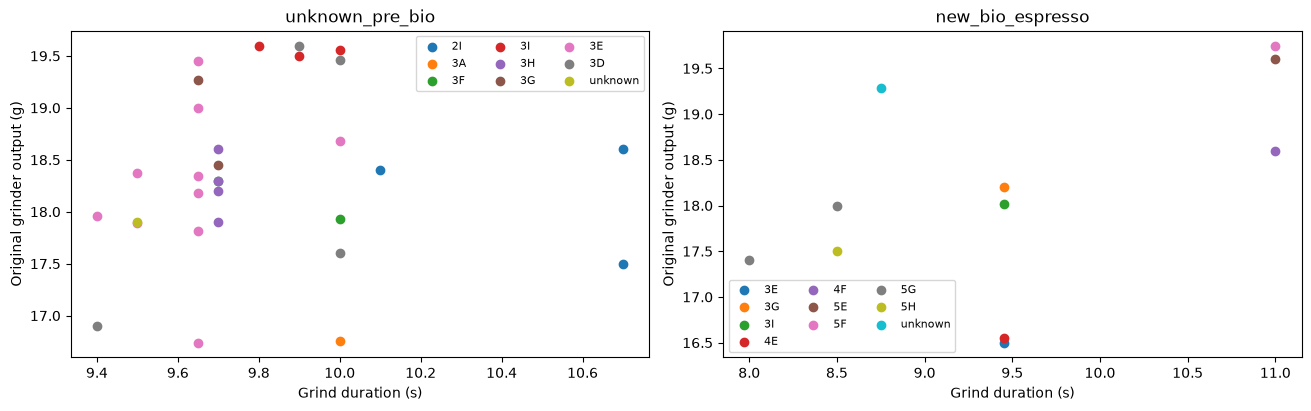

,block,bean,setting,puck,sequences,metric,n,mean,median,sd,mad,min,max
0,0,unknown_pre_bio,2I,None,"[1, 3, 4]",grind_duration_s,3,10.500000,10.700000,0.346410,0.000000,10.100000,10.700000
1,0,unknown_pre_bio,2I,None,"[1, 3, 4]",grinder_output_g,3,18.166667,18.400000,0.585947,0.200000,17.500000,18.600000
2,0,unknown_pre_bio,2I,None,"[1, 3, 4]",rate,3,1.731871,1.738318,0.093301,0.083464,1.635514,1.821782
3,0,unknown_pre_bio,3A,None,[5],grind_duration_s,1,10.000000,10.000000,NaN,0.000000,10.000000,10.000000
4,0,unknown_pre_bio,3A,None,[5],grinder_output_g,1,16.760000,16.760000,NaN,0.000000,16.760000,16.760000
5,0,unknown_pre_bio,3A,None,[5],rate,1,1.676000,1.676000,NaN,0.000000,1.676000,1.676000
6,0,unknown_pre_bio,3F,None,"[6, 15]",grind_duration_s,2,9.850000,9.850000,0.212132,0.150000,9.700000,10.000000
7,0,unknown_pre_bio,3F,None,"[6, 15]",grinder_output_g,2,18.115000,18.115000,0.261630,0.185000,17.930000,18.300000
8,0,unknown_pre_bio,3F,None,"[6, 15]",rate,2,1.839799,1.839799,0.066184,0.046799,1.793000,1.886598
9,0,unknown_pre_bio,3I,None,"[7, 8, 9]",grind_duration_s,3,9.900000,9.900000,0.100000,0.100000,9.800000,10.000000


count       mean  median       std    min  \
bean            setting duration_s                                              
unknown_pre_bio 2I      10.70           2  18.050000   18.05  0.777817  17.50   
                3H      9.70            4  18.250000   18.25  0.288675  17.90   
                3E      9.65            6  18.253333   18.26  0.947537  16.74   
                3D      10.00           2  18.530000   18.53  1.315219  17.60   
                3E      9.50            2  18.130000   18.13  0.339411  17.89   

                                      max  
bean            setting duration_s         
unknown_pre_bio 2I      10.70       18.60  
                3H      9.70        18.60  
                3E      9.65        19.45  
                3D      10.00       19.46  
                3E      9.50        18.37

,bean,n,mean,median,sd,mad,min,max
0,unknown_pre_bio,30,1.873807,1.885404,0.095558,0.062109,1.635514,2.015544
1,new_bio_espresso,11,1.922915,1.906878,0.186855,0.155556,1.690909,2.203429


In [3]:
output = eligible(shots, "output")
output_frame = pd.DataFrame(
    [
        {
            "sequence": s.sequence,
            "bean": s.bean,
            "block": s.block,
            "setting": s.setting or "unknown",
            "duration_s": metric(s, "grind_duration_s"),
            "output_g": metric(s, "grinder_output_g"),
            "rate_g_s": metric(s, "rate"),
            "status": s.raw["transcription_status"],
        }
        for s in output
    ]
)
fig, axes = plt.subplots(1, 2, figsize=(13, 4), layout="constrained")
for ax, (bean, frame) in zip(axes, output_frame.groupby("bean", sort=False), strict=True):
    for setting, group in frame.groupby("setting", sort=False):
        ax.scatter(group.duration_s, group.output_g, label=setting)
    ax.set(title=bean, xlabel="Grind duration (s)", ylabel="Original grinder output (g)")
    ax.legend(ncol=3, fontsize=8)
plt.show()
display(pd.DataFrame(report["output_groups"]))
display(
    output_frame.groupby(["bean", "setting", "duration_s"], sort=False)
    .output_g.agg(["count", "mean", "median", "std", "min", "max"])
    .query("count >= 2")
)
display(
    pd.DataFrame(
        [
            {"bean": bean, **describe([metric(s, "rate") for s in output if s.bean == bean])}
            for bean in dict.fromkeys(s.bean for s in shots)
        ]
    )
)

## B. Extraction: raw time, actual yield, and the T36 approximation
The three outcomes share exactly the same extraction-eligible shots. Points retain all observations; black bars are medians. T36 is a crude derived value, not an observed target time. Repeated-setting groups also match block and puck-dose interpretation/target. Identical labels across bean groups must not be treated as replicates.


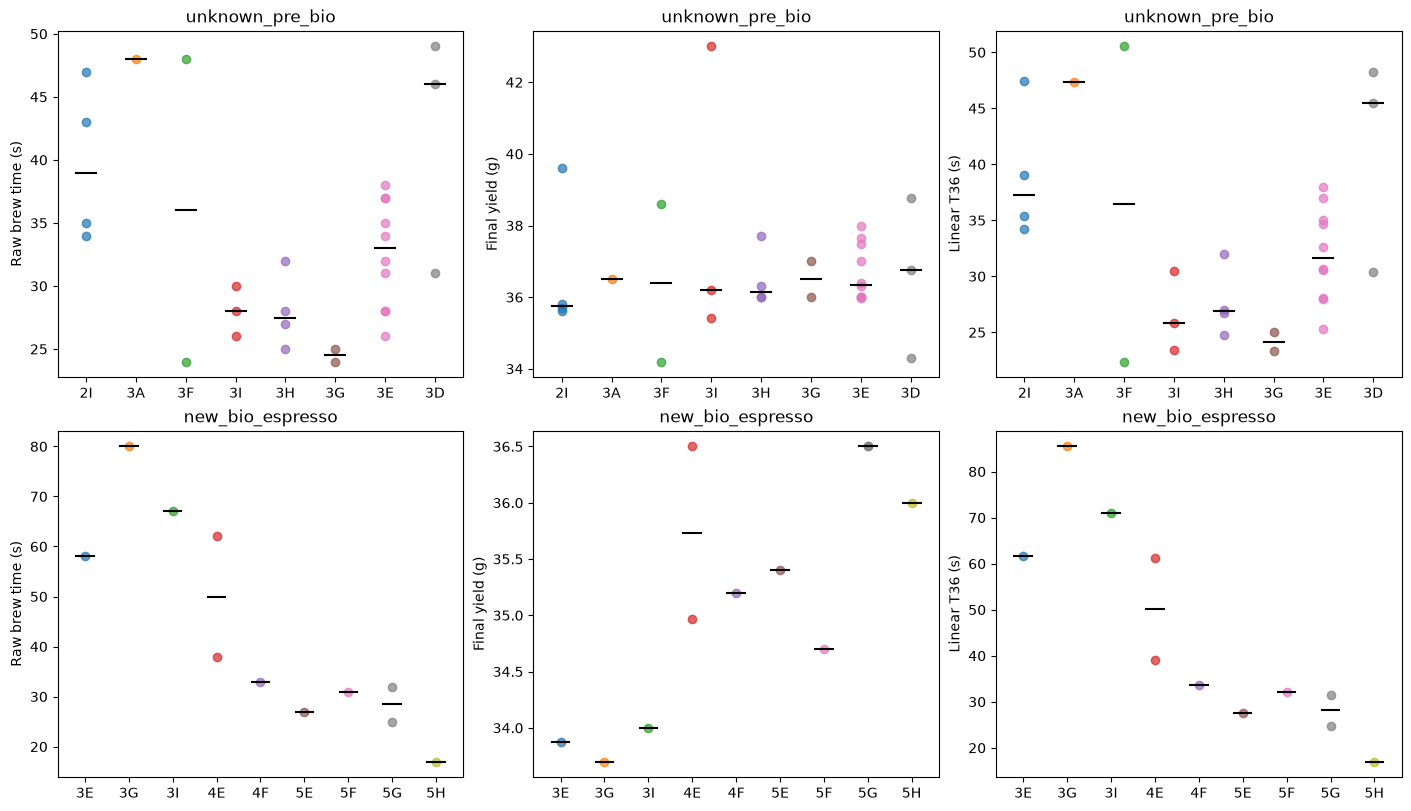

,block,bean,setting,puck,sequences,metric,n,mean,median,sd,mad,min,max
0,0,unknown_pre_bio,2I,"(approximate_target, 18.0)","[1, 2, 3, 4]",brew_duration_s,4,39.750000,39.000000,6.291529,4.500000,34.000000,47.000000
1,0,unknown_pre_bio,2I,"(approximate_target, 18.0)","[1, 2, 3, 4]",final_yield_g,4,36.675000,35.750000,1.951709,0.100000,35.600000,39.600000
2,0,unknown_pre_bio,2I,"(approximate_target, 18.0)","[1, 2, 3, 4]",t36,4,39.017267,37.242084,5.961756,2.450482,34.189944,47.394958
3,0,unknown_pre_bio,3A,"(approximate_target, 18.0)",[5],brew_duration_s,1,48.000000,48.000000,NaN,0.000000,48.000000,48.000000
4,0,unknown_pre_bio,3A,"(approximate_target, 18.0)",[5],final_yield_g,1,36.500000,36.500000,NaN,0.000000,36.500000,36.500000
5,0,unknown_pre_bio,3A,"(approximate_target, 18.0)",[5],t36,1,47.342466,47.342466,NaN,0.000000,47.342466,47.342466
6,0,unknown_pre_bio,3F,"(approximate_target, 18.0)","[6, 15]",brew_duration_s,2,36.000000,36.000000,16.970563,12.000000,24.000000,48.000000
7,0,unknown_pre_bio,3F,"(approximate_target, 18.0)","[6, 15]",final_yield_g,2,36.400000,36.400000,3.111270,2.200000,34.200000,38.600000
8,0,unknown_pre_bio,3F,"(approximate_target, 18.0)","[6, 15]",t36,2,36.454868,36.454868,19.900033,14.071448,22.383420,50.526316
9,0,unknown_pre_bio,3I,"(approximate_target, 18.0)","[7, 8, 9]",brew_duration_s,3,28.000000,28.000000,2.000000,2.000000,26.000000,30.000000


,bean,metric,groups,n,pooled_within_sd
0,unknown_pre_bio,brew_duration_s,7,28,6.139839
1,unknown_pre_bio,t36,7,28,6.557094
2,new_bio_espresso,brew_duration_s,2,4,12.500000
3,new_bio_espresso,t36,2,4,11.543949


In [4]:
extraction = eligible(shots, "extraction")
fig, axes = plt.subplots(2, 3, figsize=(14, 8), layout="constrained")
for row, bean in enumerate(dict.fromkeys(s.bean for s in shots)):
    members = [s for s in extraction if s.bean == bean]
    settings = list(dict.fromkeys(s.setting for s in members))
    for ax, field, label in zip(
        axes[row],
        ("brew_duration_s", "final_yield_g", "t36"),
        ("Raw brew time (s)", "Final yield (g)", "Linear T36 (s)"),
        strict=True,
    ):
        for index, setting in enumerate(settings):
            values = [metric(s, field) for s in members if s.setting == setting]
            ax.scatter([index] * len(values), values, alpha=0.7)
            ax.plot([index - 0.2, index + 0.2], [describe(values)["median"]] * 2, color="black")
        ax.set(xticks=range(len(settings)), xticklabels=settings, title=bean, ylabel=label)
plt.show()
display(pd.DataFrame(report["extraction_groups"]))
display(pd.DataFrame(report["variability"]))

## C. Robust description, not retrospective bad-shot diagnosis
Modified absolute z-score = `0.67448975 * abs(x - median) / MAD`; flag above 3.5 only in exact extraction groups with at least five observations. Zero MAD is explicitly unscorable. Group sizes below five are too sparse for this rule. No flag removes a shot, and full-group retrospective scores never enter rolling predictions.

Only the earlier 3E group (10 shots) qualifies; it produces no flags for either time representation. The 24/48 s pair at earlier 3F and the 38/62 s pair at newer 4E are large repeat differences, but two observations cannot identify which shot is anomalous. In particular the 17 s shot at newer 5H is a singleton, not a known channeling event. Means/SDs and medians/MADs above show sensitivity without inventing bad-shot labels.


In [5]:
flags = pd.DataFrame(report["flags"])
display(flags)
print("Scorable shots per metric:", flags.groupby("metric").size().to_dict())
print("Flagged:", flags.loc[flags.flag.eq(True), "sequence"].tolist())

,sequence,bean,setting,metric,value,modified_z,flag
0,18,unknown_pre_bio,3E,brew_duration_s,31.000000,0.337245,False
1,19,unknown_pre_bio,3E,brew_duration_s,26.000000,1.180357,False
2,23,unknown_pre_bio,3E,brew_duration_s,28.000000,0.843112,False
3,24,unknown_pre_bio,3E,brew_duration_s,32.000000,0.168622,False
4,25,unknown_pre_bio,3E,brew_duration_s,38.000000,0.843112,False
5,27,unknown_pre_bio,3E,brew_duration_s,34.000000,0.168622,False
6,29,unknown_pre_bio,3E,brew_duration_s,28.000000,0.843112,False
7,30,unknown_pre_bio,3E,brew_duration_s,37.000000,0.674490,False
8,31,unknown_pre_bio,3E,brew_duration_s,35.000000,0.337245,False
9,32,unknown_pre_bio,3E,brew_duration_s,37.000000,0.674490,False


Scorable shots per metric: {'brew_duration_s': 10, 't36': 10}
Flagged: []


## D. Chronology and possible retention
The timeline displays missing extraction values as gaps. Changed/unchanged comparisons are descriptive and heavily confounded by the chosen setting. The strongest available simple comparison is a first changed shot and its immediate repeat at the same setting and puck interpretation. Previous settings are categorical; no signed or linear grind-distance feature is invented.


,sequence,bean,block,setting,previous_setting,changed,brew_duration_s,t36
0,2,unknown_pre_bio,0,2I,2I,False,34.0,34.189944
1,3,unknown_pre_bio,0,2I,2I,False,43.0,39.090909
2,4,unknown_pre_bio,0,2I,2I,False,47.0,47.394958
3,5,unknown_pre_bio,0,3A,2I,True,48.0,47.342466
4,6,unknown_pre_bio,0,3F,3A,True,48.0,50.526316
5,7,unknown_pre_bio,0,3I,3F,True,30.0,30.482642
6,8,unknown_pre_bio,0,3I,3I,False,26.0,25.856354
7,9,unknown_pre_bio,0,3I,3I,False,28.0,23.441860
8,10,unknown_pre_bio,0,3H,3I,True,28.0,26.737401
9,11,unknown_pre_bio,0,3H,3H,False,27.0,27.000000


count       mean     median        std
bean             setting changed                                        
unknown_pre_bio  2I      False        3  40.225270  39.090909   6.675191
                 3A      True         1  47.342466  47.342466        NaN
                 3F      True         2  36.454868  36.454868  19.900033
                 3I      True         1  30.482642  30.482642        NaN
                         False        2  24.649107  24.649107   1.707304
                 3H      True         1  26.737401  26.737401        NaN
                         False        3  27.931129  27.000000   3.692433
                 3G      True         1  25.000000  25.000000        NaN
                         False        1  23.351351  23.351351        NaN
                 3E      True         2  29.325783  29.325783   1.885936
                         False        8  32.666293  33.679725   4.427876
                 3D      True         1  30.350829  30.350829        NaN
                         False        2  46.895360  46.895360   1.958012
new_bio_espresso 3G      True         1  85.459941  85.459941        NaN
                 3I      True         1  70.941176  70.941176        NaN
                 4E      True         1  61.150685  61.150685        NaN
                 4F      True         1  33.750000  33.750000        NaN
                 5E      True         1  27.457627  27.457627        NaN
                 5F      True         1  32.161383  32.161383        NaN
                 5G      True         1  31.561644  31.561644        NaN
                         False        1  24.657534  24.657534        NaN
                 5H      True         1  17.000000  17.000000        NaN

,first,repeat,bean,setting,previous_setting,raw_repeat_minus_first_s,t36_repeat_minus_first_s
0,7,8,unknown_pre_bio,3I,3F,-4.0,-4.626288
1,10,11,unknown_pre_bio,3H,3I,-1.0,0.262599
2,16,17,unknown_pre_bio,3G,3F,-1.0,-1.648649
3,18,19,unknown_pre_bio,3E,3G,-5.0,-5.362043
4,20,21,unknown_pre_bio,3D,3E,18.0,15.160006
5,23,24,unknown_pre_bio,3E,3D,4.0,2.605385
6,47,48,new_bio_espresso,5G,5F,-7.0,-6.904110


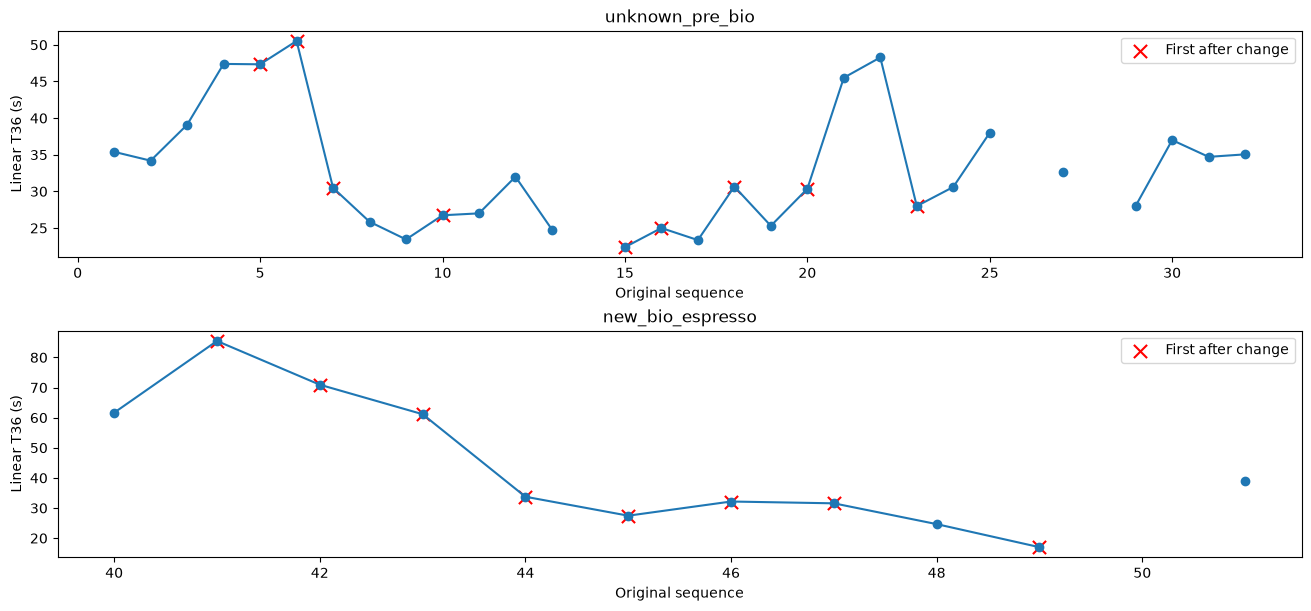

In [6]:
chronology = pd.DataFrame(report["chronology"])
display(chronology)
display(
    chronology.groupby(["bean", "setting", "changed"], sort=False).t36.agg(
        ["count", "mean", "median", "std"]
    )
)
followups = pd.DataFrame(report["change_followups"])
display(followups)
fig, axes = plt.subplots(2, 1, figsize=(13, 6), layout="constrained")
for ax, bean in zip(axes, dict.fromkeys(s.bean for s in shots), strict=True):
    members = [s for s in shots if s.bean == bean]
    ax.plot(
        [s.sequence for s in members],
        [
            s.t36_linear_approx_s if not exclusion_reasons(s, "extraction") else float("nan")
            for s in members
        ],
        marker="o",
    )
    changed = chronology.loc[(chronology.bean == bean) & chronology.changed]
    ax.scatter(
        changed.sequence, changed.t36, marker="x", s=90, color="red", label="First after change"
    )
    ax.set(title=bean, xlabel="Original sequence", ylabel="Linear T36 (s)")
    ax.legend()
plt.show()

There are 37 extraction shots with known previous settings (17 changed, 20 unchanged), but only seven first/repeat pairs (six earlier, one newer). Repeat-minus-first T36 goes in both directions. Missing setting 50 prevents treating 51 as a known transition. The large gap between newer 4E shots 43 and 51 is not an immediate retention replicate. There is insufficient evidence for previous-setting predictive value or a latent retention model.


## E. Minimal chronological baselines
**Dose:** from the previous compatible shot, `t_new = t_old * 18 / output_old`. Score the implied previous output rate at the next shot's **actual** grind duration. Compatibility requires immediate same-setting neighbours in the same block, with both duration/output pairs known. Compare with simply carrying forward the last measured output. Report recommendations alongside observed durations; do not pretend the operator followed them.

**Extraction:** expanding past-only median at the same exact setting/block/puck target, minimum one prior observation. Score both baselines against the same observed raw brew duration. For the normalized method, multiply the past median T36 by the held-out **observed yield / 36**. This is conditional reconstruction using an outcome-side yield, not a deployable next-shot predictor, a measurement of true T36 error, or a causal experiment. All observations are retained; no future-derived outlier filter is applied.


In [7]:
display(pd.DataFrame(report["dose_pairs"]))
display(pd.DataFrame(report["rolling_extraction"]))
display(pd.DataFrame(report["errors"]))

,previous,sequence,bean,setting,recommended_duration_s,actual_duration_s,prediction_g,actual_g,error_g,carry_output_error_g,rate_change_pct
0,3,4,unknown_pre_bio,2I,11.005714,10.70,17.500000,18.60,-1.100000,-1.10,6.285714
1,7,8,unknown_pre_bio,3I,9.202454,9.90,19.364400,19.50,-0.135600,0.06,0.700254
2,8,9,unknown_pre_bio,3I,9.138462,9.80,19.303030,19.60,-0.296970,-0.10,1.538462
3,10,11,unknown_pre_bio,3H,9.387097,9.70,18.600000,17.90,0.700000,0.70,-3.763441
4,11,12,unknown_pre_bio,3H,9.754190,9.70,17.900000,18.30,-0.400000,-0.40,2.234637
5,12,13,unknown_pre_bio,3H,9.540984,9.70,18.300000,18.20,0.100000,0.10,-0.546448
6,16,17,unknown_pre_bio,3G,9.463415,9.65,18.354897,19.27,-0.915103,-0.82,4.985607
7,18,19,unknown_pre_bio,3E,10.376344,10.00,17.347150,18.68,-1.332850,-1.94,7.683393
8,20,21,unknown_pre_bio,3D,10.227273,10.00,17.600000,19.46,-1.860000,-1.86,10.568182
9,21,22,unknown_pre_bio,3D,9.249743,9.90,19.265400,19.60,-0.334600,-0.14,1.736792


,sequence,bean,setting,n_train,train_through,raw_error_s,normalized_error_s
0,2,unknown_pre_bio,2I,1,1,1.0,1.196629
1,3,unknown_pre_bio,2I,2,2,-8.5,-4.729239
2,4,unknown_pre_bio,2I,3,3,-12.0,-11.901685
3,8,unknown_pre_bio,3I,1,7,4.0,4.651990
4,9,unknown_pre_bio,3I,2,8,0.0,5.646900
5,11,unknown_pre_bio,3H,1,10,1.0,-0.262599
6,12,unknown_pre_bio,3H,2,11,-4.5,-5.131300
7,13,unknown_pre_bio,3H,3,12,3.0,2.225000
8,15,unknown_pre_bio,3F,1,6,24.0,30.175439
9,17,unknown_pre_bio,3G,1,16,1.0,1.694444


,bean,method,n,mae,rmse,median_absolute_error
0,unknown_pre_bio,error_g,16,0.688860,0.869909,0.505000
1,unknown_pre_bio,carry_output_error_g,16,0.703750,0.930920,0.505000
2,unknown_pre_bio,raw_error_s,21,5.809524,8.189715,4.000000
3,unknown_pre_bio,normalized_error_s,21,6.221315,9.080982,4.651990
4,new_bio_espresso,error_g,1,0.497500,0.497500,0.497500
5,new_bio_espresso,carry_output_error_g,1,0.590000,0.590000,0.590000
6,new_bio_espresso,raw_error_s,2,15.500000,17.677670,15.500000
7,new_bio_espresso,normalized_error_s,2,14.200548,15.921792,14.200548


## Sensitivity to explicit uncertainty
Shot 40 has approximate grinder output; excluding it changes the descriptive rate distribution but none of the compatible dose pairs. Rows 14 and 28 have UNKNOWN correction: list their derived T36, then show what repeated-setting SDs would look like **if** the entered 18 g were accepted as a comparable dose. This is a separate sensitivity, never a modification of the loaded rows or the primary eligibility rules.


In [8]:
display(
    pd.DataFrame(
        [
            {
                "bean": bean,
                "exclude_approximate": exclude,
                **describe(
                    [
                        metric(s, "rate")
                        for s in output
                        if s.bean == bean
                        and (not exclude or s.raw["transcription_status"] != "approximate")
                    ]
                ),
            }
            for bean in dict.fromkeys(s.bean for s in shots)
            for exclude in (False, True)
        ]
    )
)
uncertain = [s for s in shots if exclusion_reasons(s, "extraction") == ("usable_puck_dose",)]
display(
    pd.DataFrame(
        [
            {
                "sequence": s.sequence,
                "mode": s.raw["dose_correction_mode"],
                "recorded_puck_g": s.numbers["puck_dose_g"],
                "t36": s.t36_linear_approx_s,
            }
            for s in uncertain
        ]
    )
)
sensitivity = pd.DataFrame(
    [
        {
            "bean": s.bean,
            "block": s.block,
            "setting": s.setting,
            "puck": s.numbers["puck_dose_g"],
            "raw": metric(s, "brew_duration_s"),
            "t36": metric(s, "t36"),
        }
        for s in shots
        if s in extraction or s in uncertain
    ]
)
display(
    sensitivity.groupby(["bean", "block", "setting", "puck"], sort=False)[["raw", "t36"]].agg(
        ["count", "median", "std"]
    )
)

,bean,exclude_approximate,n,mean,median,sd,mad,min,max
0,unknown_pre_bio,False,30,1.873807,1.885404,0.095558,0.062109,1.635514,2.015544
1,unknown_pre_bio,True,30,1.873807,1.885404,0.095558,0.062109,1.635514,2.015544
2,new_bio_espresso,False,11,1.922915,1.906878,0.186855,0.155556,1.690909,2.203429
3,new_bio_espresso,True,10,1.940603,1.916402,0.187003,0.153750,1.690909,2.203429


,sequence,mode,recorded_puck_g,t36
0,14,UNKNOWN,18.0,26.00000
1,28,UNKNOWN,18.0,28.49345


raw                     t36             \
                                    count median        std count     median   
bean             block setting puck                                            
unknown_pre_bio  0     2I      18.0     4   39.0   6.291529     4  37.242084   
                       3A      18.0     1   48.0        NaN     1  47.342466   
                       3F      18.0     2   36.0  16.970563     2  36.454868   
                       3I      18.0     3   28.0   2.000000     3  25.856354   
                       3H      18.0     5   27.0   2.701851     5  26.737401   
                       3G      18.0     2   24.5   0.707107     2  24.175676   
                       3E      18.0    11   32.0   4.197402    11  30.659341   
                       3D      18.0     3   46.0   9.643651     3  45.510836   
new_bio_espresso 1     3E      18.0     1   58.0        NaN     1  61.647476   
                       3G      18.0     1   80.0        NaN     1  85.459941   
                       3I      18.0     1   67.0        NaN     1  70.941176   
                       4E      18.0     2   50.0  16.970563     2  50.134965   
                       4F      18.0     1   33.0        NaN     1  33.750000   
                       5E      18.0     1   27.0        NaN     1  27.457627   
                       5F      18.0     1   31.0        NaN     1  32.161383   
                       5G      18.0     2   28.5   4.949747     2  28.109589   
                       5H      18.0     1   17.0        NaN     1  17.000000   

                                                
                                           std  
bean             block setting puck             
unknown_pre_bio  0     2I      18.0   5.961756  
                       3A      18.0        NaN  
                       3F      18.0  19.900033  
                       3I      18.0   3.577823  
                       3H      18.0   2.759956  
                       3G      18.0   1.165771  
                       3E      18.0   4.120926  
                       3D      18.0   9.651808  
new_bio_espresso 1     3E      18.0        NaN  
                       3G      18.0        NaN  
                       3I      18.0        NaN  
                       4E      18.0  15.578581  
                       4F      18.0        NaN  
                       5E      18.0        NaN  
                       5F      18.0        NaN  
                       5G      18.0   4.881943  
                       5H      18.0        NaN

## Conclusions and smallest next step
- Actual yield changes interpretation: shot 9 is 28 s at 43 g, giving a crude T36 of 23.44 s. Preserve both raw measurements regardless of normalization choice.
- Normalization is **not consistently variance-reducing**: pooled within-setting SD changes 6.14 to 6.56 s in the earlier group (28 shots, seven groups), and 12.50 to 11.54 s in the newer group (four shots, two groups). Reduced SD alone would not prove accuracy.
- Past-only conditional extraction MAE changes 5.81 to 6.22 s (21 comparisons) and 15.50 to 14.20 s (two). This weakens automatic adoption of linear normalization; it does not reject the value of using yield.
- Proportional dose prediction has about 0.68 g MAE over 17 adjacent pairs, mostly the earlier bean group. Only seven pairs change duration; duration ranges are narrow/confounded. Exact proportional physics and controller convergence remain unvalidated.
- Setting-associated output-rate differences are visible but unseparated from chronology/beans. Repeated identical durations also vary. No calibrated Sette mapping is justified.
- Robust descriptive summaries are justified; superiority of any robust predictor remains untested. The limited MAD screen identifies no outliers in its sole sufficiently large group.
- Retention evidence is insufficient. Known bean labels differ sharply at matching settings, and actual sessions, bean age, preparation, purge history and timestamps are unavailable.

**Next implementation step:** a small typed proportional-dose baseline with past-only, same-block median-rate comparator and recommendation records for prospective evaluation. Defer extraction regression/retention until targeted repeated observations resolve the confounding. This notebook does not implement that next phase.

See `docs/historical-analysis.md` for the research record. No coffee-to-target, causal savings, or uncertainty-calibration claim can be made from these data.
